Cell 1: **Import Libraries**

In [ ]:
!pip install -q transformers torch

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving social_media_sentiment_1000.csv to social_media_sentiment_1000.csv


**Cell 2: Load Dataset**

In [ ]:
df = pd.read_csv("social_media_sentiment_1000.csv")

print("Shape:", df.shape)

df.head()

Shape: (1000, 7)


,text,label,platform,timestamp,likes,retweets,followers
0,"This running shoes is incredible, highly recom...",positive,TikTok,18-09-2024 22:40,59,11,17775
1,"Wow, this curtains blew me away completely!",positive,Twitter,09-12-2024 07:40,418,56,43808
2,The laptop stand stopped working after two uses.,negative,TikTok,17-10-2024 12:37,33,4,11628
3,"This monitor is incredible, highly recommend!",positive,Twitter,11-11-2024 12:07,658,251,1408
4,Disgusting quality on this wallet. Never again.,negative,Twitter,11-01-2024 11:26,26,4,10913


**Cell 3: Dataset Exploration**

In [ ]:
df.columns

Index(['text', 'label', 'platform', 'timestamp', 'likes', 'retweets',
       'followers'],
      dtype='object')

In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       1000 non-null   object
 1   label      1000 non-null   object
 2   platform   1000 non-null   object
 3   timestamp  1000 non-null   object
 4   likes      1000 non-null   int64 
 5   retweets   1000 non-null   int64 
 6   followers  1000 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 54.8+ KB


,likes,retweets,followers
count,1000.000000,1000.000000,1000.000000
mean,224.980000,51.669000,17070.659000
std,209.915021,59.766441,12073.166627
min,0.000000,0.000000,93.000000
25%,59.000000,9.000000,7483.250000
50%,146.000000,20.000000,15034.500000
75%,344.000000,80.250000,24367.250000
max,799.000000,300.000000,49783.000000


**Cell 4: Missing Values**

In [ ]:
df.isnull().sum()

,0
text,0
label,0
platform,0
timestamp,0
likes,0
retweets,0
followers,0


In [ ]:
df.dropna(inplace=True)

print(df.shape)

(1000, 7)


**Cell 5: Remove Duplicates**

In [ ]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (1000, 7)


*Cell 6: Emoji Processing*

In [ ]:
def convert_emojis(text):
    return emoji.demojize(str(text))

df['text'] = df['text'].apply(convert_emojis)

df[['text']].head()

,text
0,"This running shoes is incredible, highly recom..."
1,"Wow, this curtains blew me away completely!"
2,The laptop stand stopped working after two uses.
3,"This monitor is incredible, highly recommend!"
4,Disgusting quality on this wallet. Never again.


**Cell 7: Text Cleaning**

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return ' '.join(words)

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,"This running shoes is incredible, highly recom...",running shoe incredible highly recommend
1,"Wow, this curtains blew me away completely!",wow curtain blew away completely
2,The laptop stand stopped working after two uses.,laptop stand stopped working two us
3,"This monitor is incredible, highly recommend!",monitor incredible highly recommend
4,Disgusting quality on this wallet. Never again.,disgusting quality wallet never


**Cell 8: Exploratory Data Analysis**
Sentiment Distribution

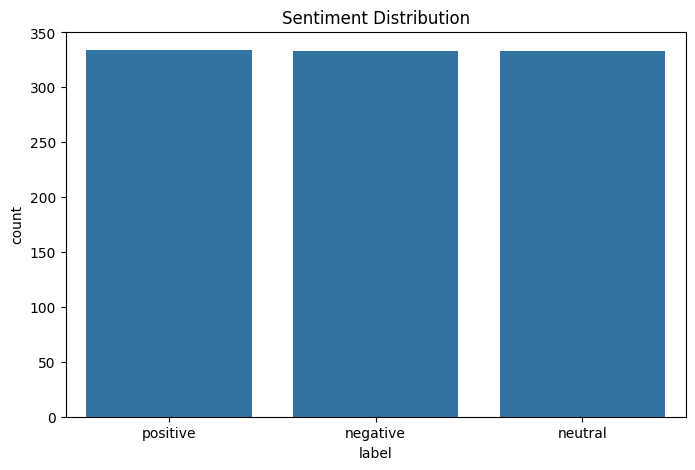

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='label')

plt.title("Sentiment Distribution")

plt.show()

 Platform Distribution:

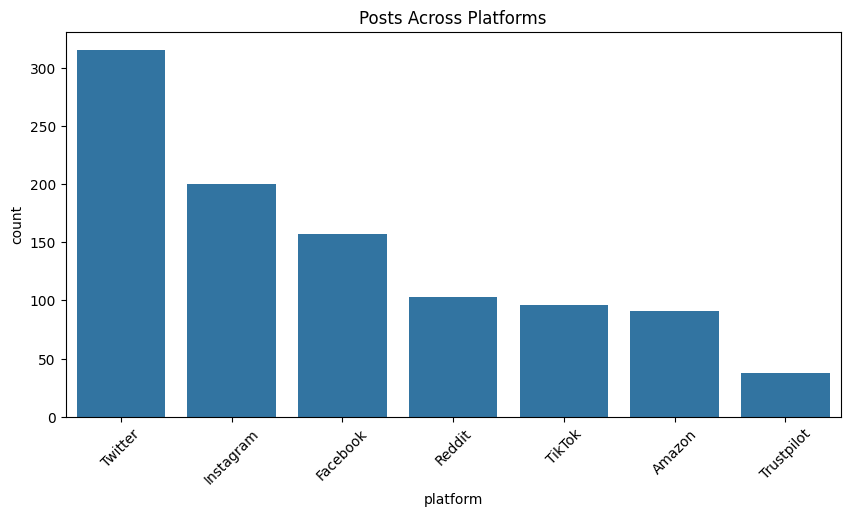

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='platform',
    order=df['platform'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Posts Across Platforms")

plt.show()

**Sentiment Across Platforms**

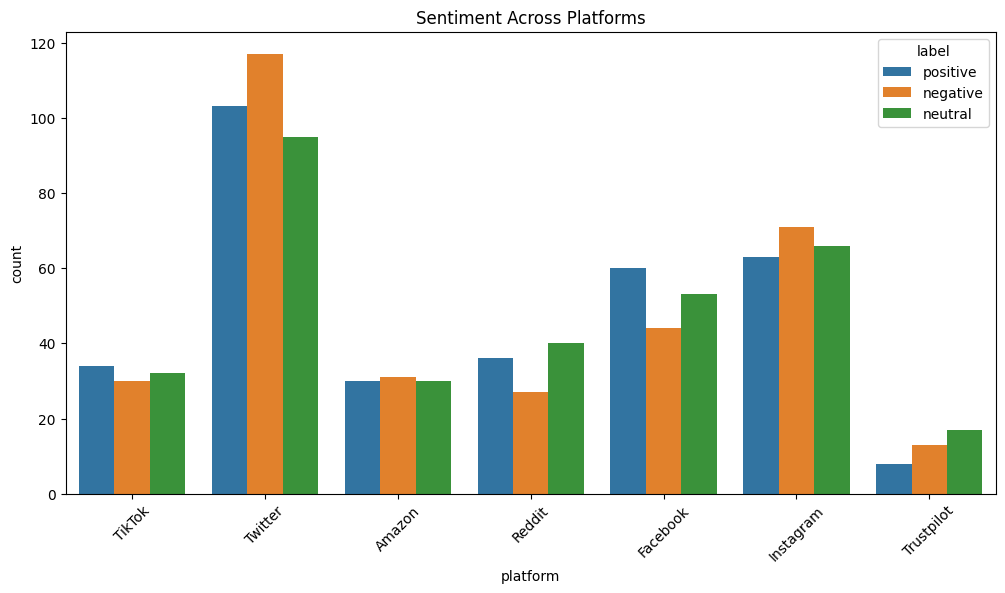

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='platform',
    hue='label'
)

plt.xticks(rotation=45)

plt.title("Sentiment Across Platforms")

plt.show()

**Likes by Sentiment**

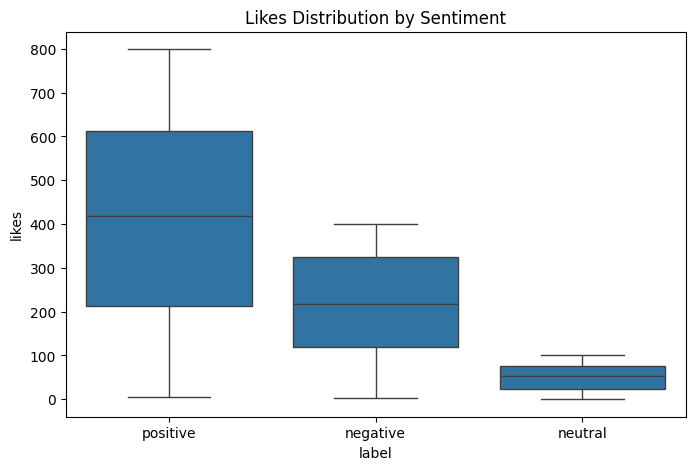

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='likes'
)

plt.title("Likes Distribution by Sentiment")

plt.show()

Retweets by Sentiment



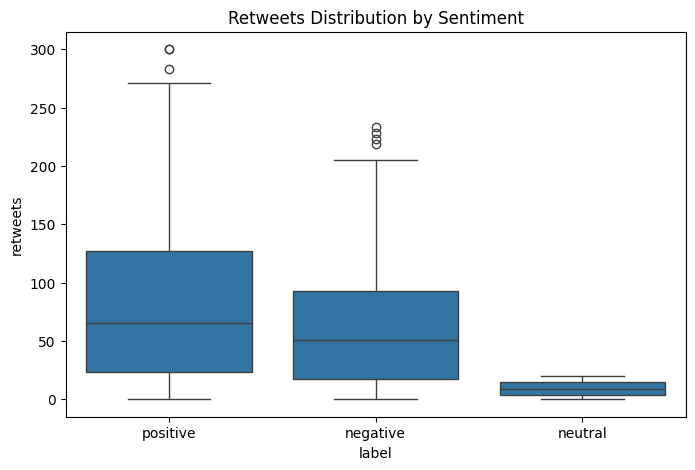

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='retweets'
)

plt.title("Retweets Distribution by Sentiment")

plt.show()

Followers Distribution

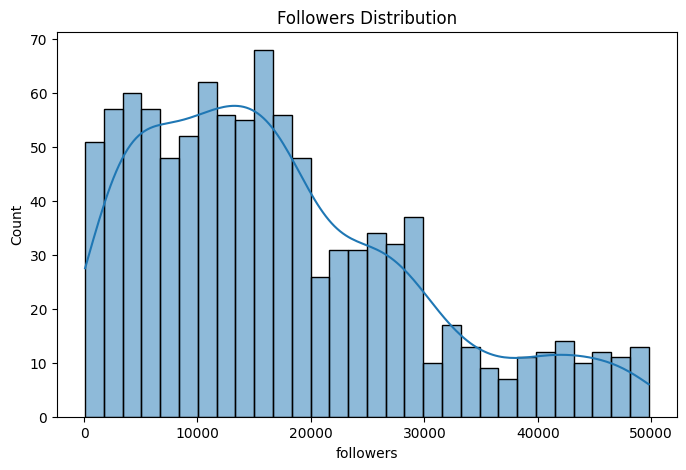

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['followers'],
    bins=30,
    kde=True
)

plt.title("Followers Distribution")

plt.show()

**Cell 9: Label Encoding**

In [ ]:
df['label'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [ ]:
encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(
    df['label']
)

df[['label', 'encoded_label']].head()

,label,encoded_label
0,positive,2
1,positive,2
2,negative,0
3,positive,2
4,negative,0


**Cell 10: TF-IDF Vectorization**

In [ ]:
X = df['clean_text']

y = df['encoded_label']

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(X)

**Cell 11: Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Cell 12: Logistic Regression**

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:",
      lr_accuracy)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    lr_pred,
    target_names=encoder.classes_
))

Logistic Regression Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        67
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**Cell 13: Logistic Regression Confusion Matrix**

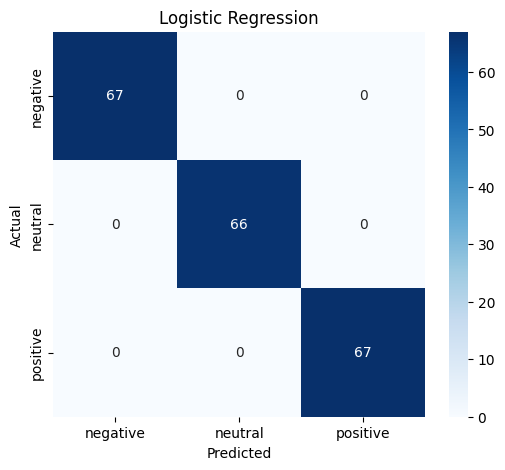

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Cell 14: Naïve Bayes**

In [ ]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naïve Bayes Accuracy:",
      nb_accuracy)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    nb_pred,
    target_names=encoder.classes_
))

Naïve Bayes Accuracy: 0.995

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      0.99      0.99        67
     neutral       0.99      1.00      0.99        66
    positive       1.00      1.00      1.00        67

    accuracy                           0.99       200
   macro avg       1.00      1.00      0.99       200
weighted avg       1.00      0.99      0.99       200



**Cell 15: Naïve Bayes Confusion Matrix**

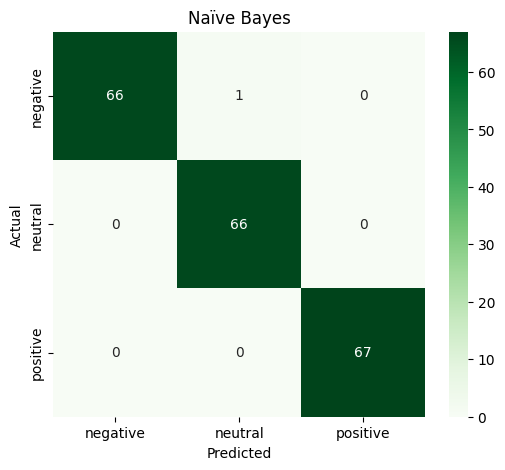

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, nb_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Naïve Bayes")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Cell 16: Support Vector Machine (SVM)**

In [ ]:
svm = SVC(
    kernel='linear',
    random_state=42
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print("SVM Accuracy:",
      svm_accuracy)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    svm_pred,
    target_names=encoder.classes_
))

SVM Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        67
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**  Cell 17: SVM Confusion Matrix**

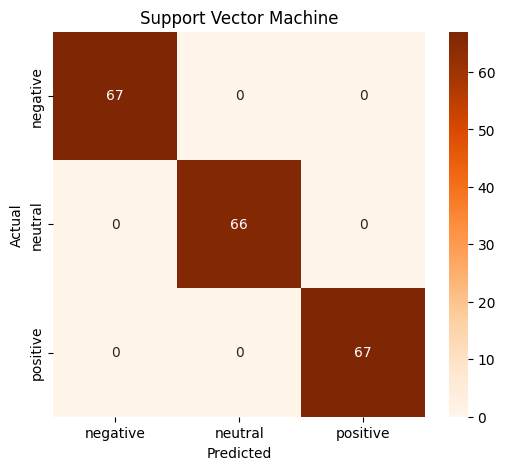

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, svm_pred),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Support Vector Machine")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Cell 18: Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      rf_accuracy)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    rf_pred,
    target_names=encoder.classes_
))

Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        67
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**Cell 19: Random Forest Confusion Matrix**

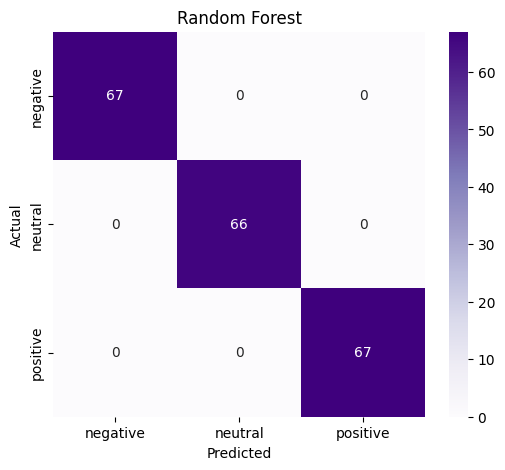

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Cell 20: Compare Model Accuracies**

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naïve Bayes',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.000
1,Naïve Bayes,0.995
2,SVM,1.000
3,Random Forest,1.000


**Cell 21: Accuracy Comparison Plot**

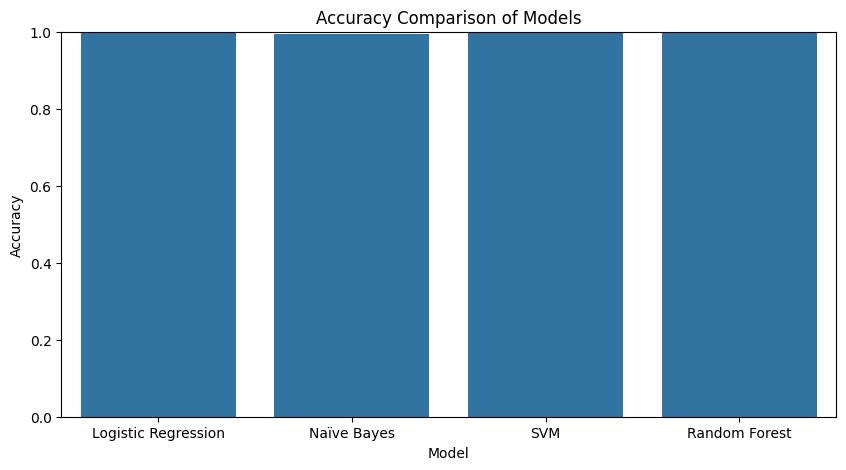

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title(
    'Accuracy Comparison of Models'
)

plt.ylim(0, 1)

plt.show()

**Cell 22: Best Performing Model**

In [ ]:
results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000
2,SVM,1.000
3,Random Forest,1.000
1,Naïve Bayes,0.995


# **PART V: DISTILBERT**

**Cell 23: Install Transformers**

In [ ]:
!pip install simpletransformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.5/332.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.6 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=a7f3e7ff452ec45c4f9beb9c16ccb04346de31007da802ccec4f53af21e18de0
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
from simpletransformers.classification import ClassificationModel

model = ClassificationModel(
    "distilbert",
    "distilbert-base-uncased",
    num_labels=3,
    use_cuda=True
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
df['label'].value_counts()

,count
label,
positive,334
negative,333
neutral,333


In [ ]:
!pip uninstall -y torchvision
!pip install -q torchvision==0.22.0
!pip install -q transformers datasets accelerate evaluate

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 MB 968.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 819.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 8.5

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [77]:
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

from torch.optim import AdamW

In [78]:
import torch
import numpy as np
import pandas as pd

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

from torch.optim import AdamW

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    RandomSampler,
    SequentialSampler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


**Cell 24: Prepare Data for DistilBERT**

In [ ]:
bert_df = df[['text', 'encoded_label']].copy()

bert_df.rename(
    columns={'encoded_label': 'label'},
    inplace=True
)

bert_df.head()

,text,label
0,"This running shoes is incredible, highly recom...",2
1,"Wow, this curtains blew me away completely!",2
2,The laptop stand stopped working after two uses.,0
3,"This monitor is incredible, highly recommend!",2
4,Disgusting quality on this wallet. Never again.,0


Cell 25: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=42,
    stratify=bert_df['label']
)

print(train_df.shape)
print(test_df.shape)

(800, 2)
(200, 2)


**Cell 26: Convert to Hugging Face Dataset**

In [ ]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

In [82]:
from transformers import DistilBertTokenizer
from transformers import DistilBertForSequenceClassification

print("Imports successful")

Imports successful


In [83]:
from torch.optim import AdamW

**Cell 27: Load Tokenizer**

In [84]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded")

Tokenizer loaded


In [85]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Model loaded")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [86]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Model loaded")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [89]:
train_texts = train_df['text']
test_texts = test_df['text']

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [92]:
train_labels = train_df['label']
test_labels = test_df['label']

train_dataset = TensorDataset(
    torch.tensor(train_encodings['input_ids']),
    torch.tensor(train_encodings['attention_mask']),
    torch.tensor(train_labels.values)
)

test_dataset = TensorDataset(
    torch.tensor(test_encodings['input_ids']),
    torch.tensor(test_encodings['attention_mask']),
    torch.tensor(test_labels.values)
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 800
Testing samples: 200


In [93]:
#Data loaders
batch_size = 16

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)

In [94]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [97]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

epochs = 3

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    model.train()

    total_loss = 0

    for batch in train_dataloader:

        batch = tuple(
            t.to(device)
            for t in batch
        )

        input_ids, attention_mask, labels = batch

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    avg_loss = total_loss / len(train_dataloader)

    print(
        f"Average Training Loss: {avg_loss:.4f}"
    )


Epoch 1/3
Average Training Loss: 0.6184

Epoch 2/3
Average Training Loss: 0.0481

Epoch 3/3
Average Training Loss: 0.0161


In [98]:
model.eval()

predictions = []

true_labels = []

with torch.no_grad():

    for batch in test_dataloader:

        batch = tuple(
            t.to(device)
            for t in batch
        )

        input_ids, attention_mask, labels = batch

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(
            logits,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

In [99]:
distilbert_accuracy = accuracy_score(
    true_labels,
    predictions
)

print(
    f"DistilBERT Accuracy: {distilbert_accuracy:.4f}"
)

DistilBERT Accuracy: 1.0000


In [100]:
print(
    classification_report(
        true_labels,
        predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        67
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



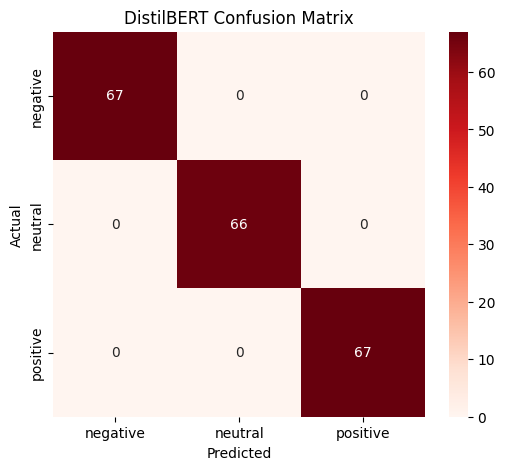

In [101]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        true_labels,
        predictions
    ),
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [102]:
#Compare with previous model
results.loc[len(results)] = [
    'DistilBERT',
    distilbert_accuracy
]

results

,Model,Accuracy
0,Logistic Regression,1.000
1,Naïve Bayes,0.995
2,SVM,1.000
3,Random Forest,1.000
4,DistilBERT,1.000


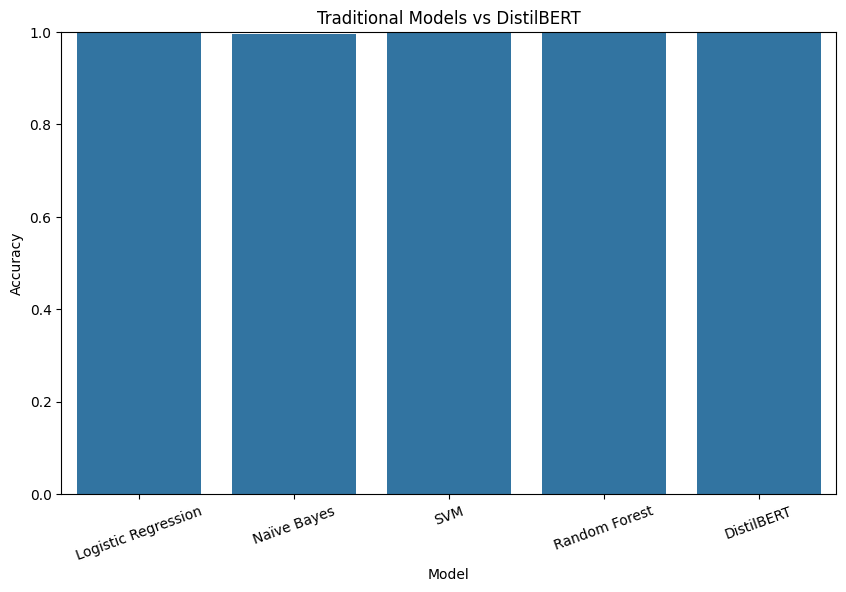

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.ylim(0, 1)

plt.title(
    "Traditional Models vs DistilBERT"
)

plt.xticks(rotation=20)

plt.show()